In [55]:
import torch
import h5py
import re
import random
import seaborn as sns
from collections import Counter
from os import listdir
from scipy.stats import chi2
from experiments_pretrained import *

In [2]:
chat_template_size = 18
model_choice = 'deepseek'

if model_choice == 'qwen':
    n_experts = 60
    n_layers = 24
    k = 4
    tokenizer = load_tokenizer_qwen()
    
if model_choice == 'deepseek':
    run_id = '20260312200327'
    n_experts = 64
    n_layers = 26
    k = 6
    tokenizer = load_tokenizer_deepseek()
    
if model_choice == 'mistral':
    run_id = '20260309124923'
    n_experts = 8
    n_layers = 32
    k = 2
    tokenizer = load_tokenizer_mistral()
    
routing_data_dir = './routing_logs/'

In [3]:
filenames = listdir(routing_data_dir)
filenames = [routing_data_dir + f for f in filenames if (run_id in f) and (model_choice in f)]

In [4]:
data = []
for filename in filenames:
    print(f"Loading from {filename}...")
    
    with h5py.File(filename, 'r') as f:
        n = int(re.split(r"-|\.", filename)[5][1:])
        
        for i in range(100):
            probs_str = f'probs_{i}'
            ae_str = f'active_experts_{i}'
            if probs_str in f:
                d = {
                    'probs': torch.tensor(f[probs_str][:]),
                    'active_experts': torch.tensor(f[ae_str]),
                    'prompt': f[probs_str].attrs['prompt'],
                    'response': f[probs_str].attrs['response'],
                    'subject': f[probs_str].attrs['subject'],
                    'prompt_tokenized': f[probs_str].attrs['prompt_tokenized'],
                    'response_tokenized': f[probs_str].attrs['response_tokenized'],
                }
                data.append(d)

Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n99.h5...


/tmp/ipykernel_648926/832749314.py:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  'active_experts': torch.tensor(f[ae_str]),


Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n23.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n29.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n100.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n76.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n22.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n6.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n140.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n96.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n109.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n103.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n95.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples150

Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n75.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n110.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n139.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n78.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n85.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n111.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n80.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n130.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n72.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n34.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples15000-tokens100-n106.h5...
Loading from ./routing_logs/deepseek-20260312200327-samples1

In [5]:
# Count token occurances in output
all_output_tokens = []
for d in data:
    #prompt_len = d['prompt_tokenized'].size + chat_template_size
    #print(prompt_len)
    output_tokens = list(d['response_tokenized'])
    all_output_tokens += output_tokens
    #eam = d['eam']
    #eam_output = eam[prompt_len:, :, :]
    
counts = Counter(all_output_tokens)

In [6]:
top_counts = counts.most_common()
top_ids = [t for (t, _) in top_counts]
top_strs = [tokenizer.decode(t) for t in top_ids]

In [7]:
per_id_activations = {}

for d in data:
    output_tokens = list(d['response_tokenized'][:100])
    prompt_len = d['prompt_tokenized'].size + chat_template_size
    probs = d['probs']
    probs_output = probs[prompt_len:, :, :]
    topk_indices = d['active_experts']
    
    for i in range(len(output_tokens)):
        t = output_tokens[i]
        if t in per_id_activations:
            per_id_activations[t].append(topk_indices[i,:,:])
        else:
            per_id_activations[t] = [topk_indices[i,:,:]]
    
for i in per_id_activations.keys():
    per_id_activations[i] = torch.cat(per_id_activations[i], dim=-2)

In [8]:
per_subject_activations = {}
for d in data:
    
    topk_indices = d['active_experts']
    topk_indices = torch.flatten(topk_indices, start_dim=0, end_dim=1)
    subject = d['subject']
    
    if subject in per_subject_activations:
        per_subject_activations[subject].append(topk_indices)
    else:
        per_subject_activations[subject] = [topk_indices]
    
    
for s in per_subject_activations.keys():
    per_subject_activations[s] = torch.cat(per_subject_activations[s], dim=0)

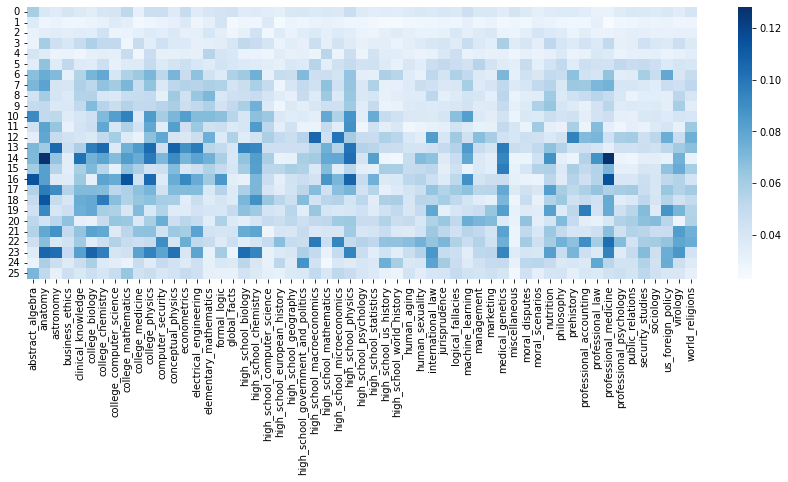

In [9]:
# Find subjects and layers with experts that are activated at a high frequency
subjects = sorted(list(per_subject_activations.keys()))
per_subject_counts = \
    {s: [Counter(per_subject_activations[s][:,l].tolist()) for l in range(n_layers)] \
     for s in subjects}

per_subject_freqs = \
    {s: [np.array([per_subject_counts[s][l][e] for e in range(n_experts)])/per_subject_counts[s][l].total() \
         for l in range(n_layers)] for s in subjects}
per_subject_max_freqs = {s: [max(per_subject_freqs[s][l]) for l in range(n_layers)]\
                        for s in subjects}

freq_thresh = 0.1
freq_thresh_mask = [[per_subject_max_freqs[s][l] for s in subjects] for l in range(n_layers)]

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.heatmap(freq_thresh_mask, cmap="Blues", cbar=True, xticklabels=subjects)
plt.show()

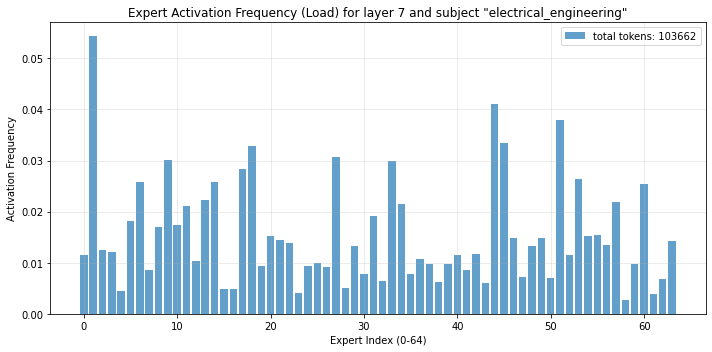

In [10]:
selected_subject = subjects[14]
selected_layer = 7

expert_counts = per_subject_counts[selected_subject][selected_layer]
expert_ids = np.array(sorted(expert_counts.keys()))
count_per_expert = np.array([expert_counts[i] for i in expert_ids])
total = expert_counts.total()
freqs = count_per_expert / total

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.bar(expert_ids, freqs, \
        label='total tokens: %d' % (total), \
        alpha=0.7)

ax.set_title(f"Expert Activation Frequency (Load) for layer {selected_layer} and subject \"{selected_subject}\"")
ax.set_xlabel(f"Expert Index (0-{n_experts})")
ax.set_ylabel("Activation Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Find tokens which activate particular experts with high frequency
ids = sorted(list(per_id_activations.keys()))
per_id_counts = \
    {i: [Counter(per_id_activations[i][:,l].tolist()) for l in range(n_layers)] \
     for i in ids}

per_id_totals = {i: sum([per_id_counts[i][l].total() for l in range(n_layers)]) for i in ids}

per_id_freqs = \
    {i: [np.array([per_id_counts[i][l][e] for e in range(n_experts)])/per_id_counts[i][l].total() \
         for l in range(n_layers)] for i in ids}
per_id_max_freqs = {i: [max(per_id_freqs[i][l]) for l in range(n_layers)]\
                        for i in ids}

/home/dylan/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


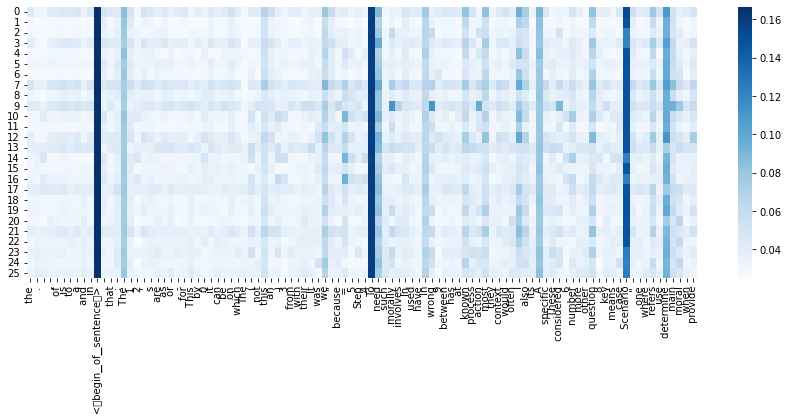

In [12]:
# Heatmap sorted by most common frequency
n_ids = 100
tokens = [tokenizer.decode(top_ids[i]) for i in range(n_ids)]
freq_mat = [[per_id_max_freqs[i][l] for i in top_ids[:n_ids]] for l in range(n_layers)]

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.heatmap(freq_mat, cmap="Blues", cbar=True, xticklabels=tokens)
plt.show()

/home/dylan/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/dylan/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/dylan/.local/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWa

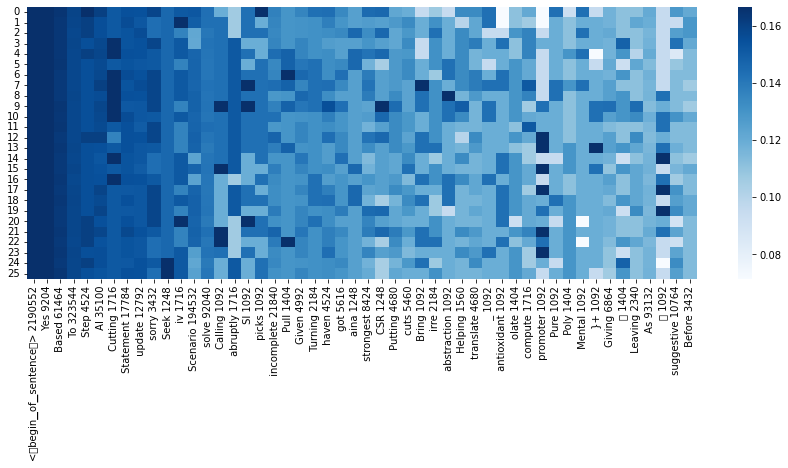

In [13]:
# Heatmap sorted by tokens with highest activation frequencies
per_id_avg_max_freqs = {i: np.mean(per_id_max_freqs[i]) for i in ids}
most_freq_ids = [i for freq, i in sorted(zip(per_id_avg_max_freqs.values(), per_id_avg_max_freqs.keys()), reverse=True)]

total_thresh = 1000
most_freq_ids_thresh = [i for i in most_freq_ids if per_id_totals[i] >= total_thresh]

n_ids = 50
tokens = [tokenizer.decode(most_freq_ids_thresh[i]) + f" {per_id_totals[most_freq_ids_thresh[i]]}" for i in range(n_ids)]
freq_mat = [[per_id_max_freqs[i][l] for i in most_freq_ids_thresh[:n_ids]] for l in range(n_layers)]

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.heatmap(freq_mat, cmap="Blues", cbar=True, xticklabels=tokens)
plt.show()

/tmp/ipykernel_648926/2242540814.py:21: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


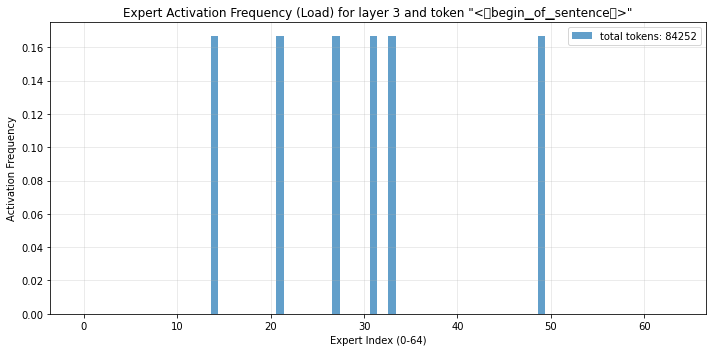

In [14]:
# Token routing histogram
selected_id = most_freq_ids_thresh[0]
selected_layer = 3

expert_counts = Counter(per_id_activations[selected_id][:,selected_layer].tolist())
expert_ids = np.array(range(n_experts))
count_per_expert = np.array([expert_counts[i] for i in expert_ids])
total = expert_counts.total()
freqs = count_per_expert / total

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.bar(expert_ids, freqs, \
        label='total tokens: %d' % (total), \
        alpha=0.7)

ax.set_title(f"Expert Activation Frequency (Load) for layer {selected_layer} and token \"{tokenizer.decode(selected_id)}\"")
ax.set_xlabel(f"Expert Index (0-{n_experts})")
ax.set_ylabel("Activation Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

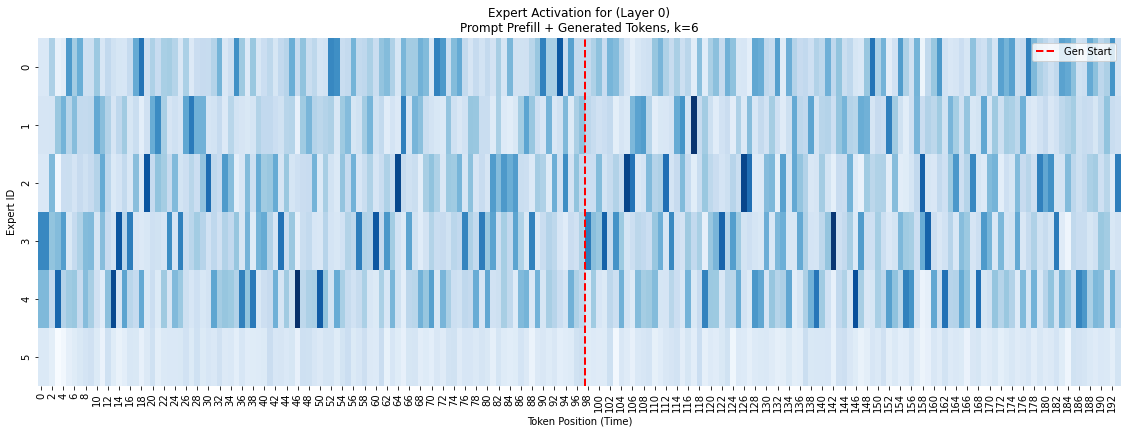

In [15]:
# Plot probabilities for a layer
selected_run = 0
selected_layer = 0

probs = data[selected_run]['probs']
probs = probs[:,:,selected_layer]
probs = torch.transpose(probs, 0, 1)

px_size = 0.1
fig, ax = plt.subplots(1, 1, figsize=(px_size*probs.size(1), px_size*n_experts))

# Draw a line to separate prefill and decoding stages
prompt_len = data[selected_run]['prompt_tokenized'].size + chat_template_size
plt.axvline(x=prompt_len, color='red', linestyle='--', linewidth=2, label="Gen Start")

sns.heatmap(probs, cmap="Blues", cbar=False, cbar_kws={'label': 'Active'})
plt.title(f"Expert Activation for (Layer {selected_layer})\nPrompt Prefill + Generated Tokens, k={k}")
plt.xlabel("Token Position (Time)")
plt.ylabel("Expert ID")
plt.legend()
plt.show()

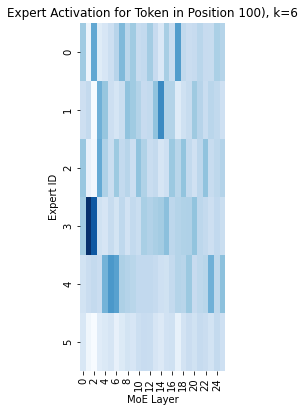

In [16]:
# Plot probabilities for an output token
selected_run = 0
selected_token_pos = 100

px_size = 0.1
fig, ax = plt.subplots(1, 1, figsize=(px_size*n_layers, px_size*n_experts))
probs = data[selected_run]['probs']
probs = probs[selected_token_pos,:,:]

sns.heatmap(probs, cmap="Blues", cbar=False, cbar_kws={'label': 'Active'})
plt.title(f"Expert Activation for Token in Position {selected_token_pos}), k={k}")
plt.xlabel("MoE Layer")
plt.ylabel("Expert ID")
plt.show()

In [17]:
selected_data = 5
selected_subject = 1
subject = subjects[selected_subject]
data_subject = [d for d in data if d['subject'] == subject]
print(data_subject[selected_data]['subject'])
print(data_subject[selected_data]['prompt'])
print(data_subject[selected_data]['response'])

anatomy
Which muscles are normally active during quiet inspiration?
 During quiet inspiration, the diaphragm and the external intercostal muscles are the primary muscles involved. The diaphragm, a dome-shaped muscle located at the base of the lungs, contracts and moves downward, thus expanding the chest cavity. Simultaneously, the external intercostal muscles, which are located between the ribs, contract and lift the ribcage, further expanding the chest cavity. These actions increase the volume of the thoracic cavity and reduce the intra-abdominal pressure, thereby reducing


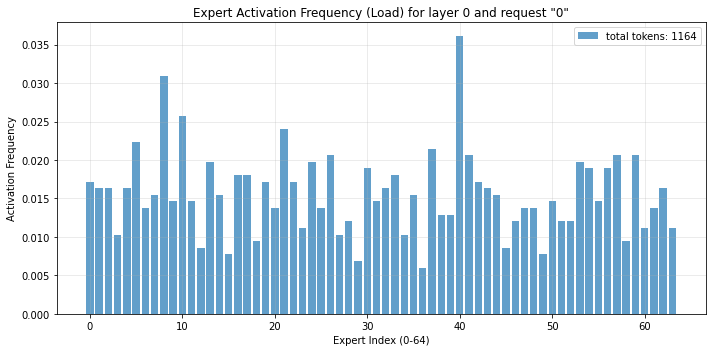

In [18]:
# Examine distributions of expert activations per-request
selected_req = 0
selected_layer = 0
data_req = data[selected_req]
activations_req = data_req['active_experts'][:, :, selected_layer].flatten().tolist()
expert_counts = Counter(activations_req)
expert_ids = np.array(sorted(expert_counts.keys()))
count_per_expert = np.array([expert_counts[i] for i in expert_ids])
total = expert_counts.total()
freqs = count_per_expert / total

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.bar(expert_ids, freqs, \
        label='total tokens: %d' % (total), \
        alpha=0.7)

ax.set_title(f"Expert Activation Frequency (Load) for layer {selected_layer} and request \"{selected_req}\"")
ax.set_xlabel(f"Expert Index (0-{n_experts})")
ax.set_ylabel("Activation Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Collect per-layer activations over all activations
per_layer_activations = [ torch.cat([per_subject_activations[s][:, l] for s in subjects]) for l in range(n_layers) ]

In [20]:
per_layer_counts = [torch.bincount(per_layer_activations[l]) for l in range(n_layers)]
per_layer_totals = [c.sum() for c in per_layer_counts]

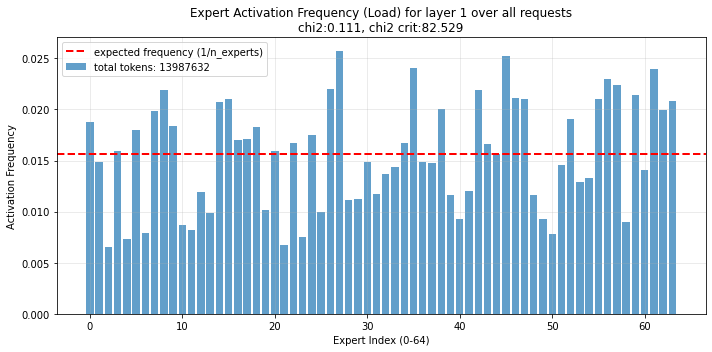

In [204]:
# Examine load balance over all activations
selected_layer = 0
expert_counts = per_layer_counts[selected_layer]
expert_ids = np.array(range(n_experts))
count_per_expert = np.array([expert_counts[i] for i in expert_ids])
total = expert_counts.total()

expected_freq = 1 / n_experts
freqs = count_per_expert / total
chisq = np.sum(np.square(freqs - expected_freq) / expected_freq)
q = 0.05
df = n_experts - 1
chisq_crit = chi2.isf(q=q, df=df)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.bar(expert_ids, freqs, \
        label='total tokens: %d' % (total), \
        alpha=0.7)
plt.axhline(y=expected_freq, color='red', linestyle='--', linewidth=2, label="expected frequency (1/n_experts)")
ax.set_title(f"Expert Activation Frequency (Load) for layer {selected_layer} over all requests\nchi2:{chisq:.3f}, chi2 crit:{chisq_crit:.3f}")
ax.set_xlabel(f"Expert Index (0-{n_experts})")
ax.set_ylabel("Activation Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

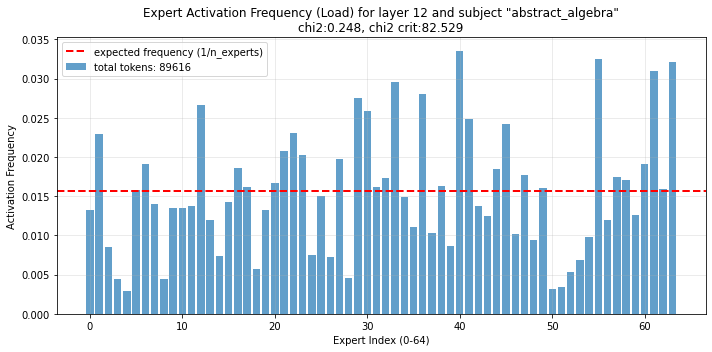

In [226]:
# Same, but per-subject
selected_layer = 12
selected_subject = subjects[0]
expert_counts = per_subject_counts[selected_subject][selected_layer]
expert_ids = np.array(range(n_experts))
count_per_expert = np.array([expert_counts[i] for i in expert_ids])
total = expert_counts.total()

expected_freq = 1 / n_experts
freqs = count_per_expert / total
chisq = np.sum(np.square(freqs - expected_freq) / expected_freq)
q = 0.05
df = n_experts - 1
chisq_crit = chi2.isf(q=q, df=df)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.bar(expert_ids, freqs, \
        label='total tokens: %d' % (total), \
        alpha=0.7)
plt.axhline(y=expected_freq, color='red', linestyle='--', linewidth=2, label="expected frequency (1/n_experts)")
ax.set_title(f"Expert Activation Frequency (Load) for layer {selected_layer} and subject \"{selected_subject}\"\nchi2:{chisq:.3f}, chi2 crit:{chisq_crit:.3f}")
ax.set_xlabel(f"Expert Index (0-{n_experts})")
ax.set_ylabel("Activation Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

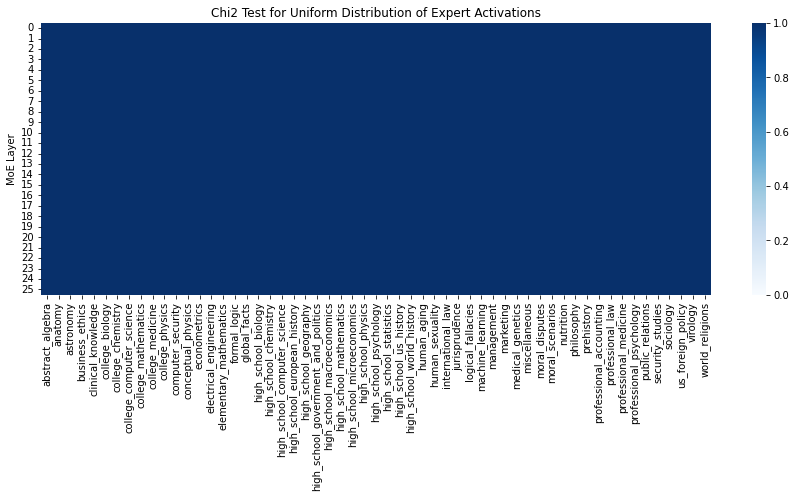

In [225]:
# Get chi2 results for all subjects / layers
q = 0.05
df = n_experts - 1

pvals = []
for s in subjects:
    
    subject_pvals = []
    for l in range(n_layers):
        
        expert_counts = per_subject_counts[s][l]
        expert_ids = np.array(range(n_experts))
        count_per_expert = np.array([expert_counts[i] for i in expert_ids])
        total = expert_counts.total()

        expected_count = total / n_experts
        freqs = count_per_expert / total
        chisq = np.sum(np.square(count_per_expert - expected_count) / expected_count)
        pval = chi2.sf(chisq, df)
        subject_pvals.append(pval)
        
    pvals.append(subject_pvals)

pvals = np.array(pvals).T
pvals_mask = pvals < q

fig, ax = plt.subplots(1, 1, figsize=(15, 5))
sns.heatmap(pvals_mask, cmap="Blues", xticklabels=subjects, vmin=0, vmax=1)
plt.title("Chi2 Test for Uniform Distribution of Expert Activations")
plt.ylabel("MoE Layer")
plt.show()

In [228]:
# Now gather all activation probabilities across layers and subjects
per_subject_probs = {}

for s in subjects:
    per_subject_probs[s] = []
    for l in range(n_layers):
        expert_counts = per_subject_counts[s][l]
        expert_ids = np.array(range(n_experts))
        count_per_expert = np.array([expert_counts[i] for i in expert_ids])
        total = expert_counts.total()
        freqs = count_per_expert / total
        per_subject_probs[s].append(freqs)

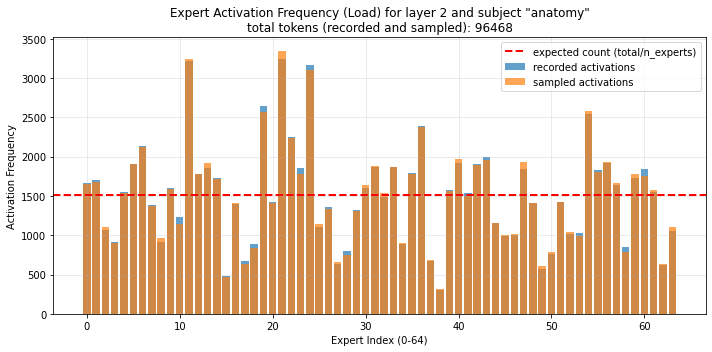

In [240]:
# Sample from a modeled distribution
selected_layer = 2
selected_subject = subjects[1]

expert_counts = per_subject_counts[selected_subject][selected_layer]
expert_ids = np.array(range(n_experts))
count_per_expert = np.array([expert_counts[i] for i in expert_ids])
total = expert_counts.total()
expected_count = total / n_experts


n_samples = total
p = per_subject_probs[selected_subject][selected_layer]
samples = np.random.choice(range(n_experts), (n_samples), p=p)
sampled_counts = Counter(samples)
sampled_count_per_expert = np.array([sampled_counts[i] for i in expert_ids])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.bar(expert_ids, count_per_expert, \
        label="recorded activations", \
        alpha=0.7)

ax.bar(expert_ids, sampled_count_per_expert, \
        label="sampled activations", \
        alpha=0.7)

plt.axhline(y=expected_count, color='red', linestyle='--', linewidth=2, label="expected count (total/n_experts)")
ax.set_title(f"Expert Activation Frequency (Load) for layer {selected_layer} and subject \"{selected_subject}\"\ntotal tokens (recorded and sampled): {total}")
ax.set_xlabel(f"Expert Index (0-{n_experts})")
ax.set_ylabel("Activation Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()